# 🧠 Modelo 8: Red Neuronal Convolucional (CNN) + Data Augmentation

Este notebook entrena una CNN básica con **Data Augmentation** para la clasificación de imágenes OCT. Aplicamos técnicas de aumento de datos para mejorar la generalización y reducir el sobreajuste.

---

In [1]:
import os
import sys

# ⚠️ IMPORTANTE: Configurar antes de importar TensorFlow
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # Suprime mensajes de TensorFlow
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'  # Desactiva mensajes de oneDNN

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import kagglehub
from sklearn.metrics import classification_report, confusion_matrix

# Suprimir warnings adicionales
import warnings
warnings.filterwarnings('ignore')
tf.get_logger().setLevel('ERROR')

# Añadir el directorio raíz al path para importar módulos locales
sys.path.append('..')
import oct_dataloader as dataloaders
import modelos.modelo_cnn as cnn_model

print("✅ Librerías importadas")

✅ Librerías importadas


In [3]:
# Configurar GPUs si están disponibles
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f" GPU detectada: {gpus[0]}")


 GPU detectada: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


## 1. Carga de Datos

In [5]:
# Descargar y preparar dataset
path = kagglehub.dataset_download("anirudhcv/labeled-optical-coherence-tomography-oct")

data_path = path
for root, dirs, files in os.walk(path):
    if 'train' in dirs and 'test' in dirs:
        data_path = root
        break

print(f"✅ Dataset en: {data_path}")

# Hiperparámetros de carga
IMG_SIZE = (128, 128)  # Mayor resolución para CNN
BATCH_SIZE = 256

train_ds, val_ds, test_ds, class_names = dataloaders.create_oct_dataloaders(
    data_path=data_path,
    img_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    train_subset_fraction=1, 
    optimize=False
)

✅ Dataset en: /home/palodo2/.cache/kagglehub/datasets/anirudhcv/labeled-optical-coherence-tomography-oct/versions/2/Dataset - train+val+test
⚙️ Configuración de DataLoaders
   • Tamaño de imagen: (128, 128)
   • Batch size: 256
   • Clases: ['CNV', 'DME', 'DRUSEN', 'NORMAL']
   • Train subset: 100.0%
   • Seed: 42

📦 Creando data loader de entrenamiento...
Found 76515 files belonging to 4 classes.
✅ Data loader de entrenamiento creado

📦 Creando data loader de validación...
Found 21861 files belonging to 4 classes.
✅ Data loader de validación creado

📦 Creando data loader de prueba...
Found 10933 files belonging to 4 classes.
✅ Data loader de prueba creado

📊 RESUMEN DE DATASETS
Train:      299 batches
Validation: 86 batches
Test:       43 batches



## 1.1. Aplicación de Data Augmentation

Aplicamos técnicas de **Data Augmentation** al dataset de entrenamiento para aumentar la variabilidad de los datos y mejorar la capacidad de generalización del modelo. Las transformaciones incluyen:

- **Rotación aleatoria**: hasta 15 grados
- **Flip horizontal**: aleatorio
- **Zoom**: hasta 10%
- **Ajustes de brillo y contraste**: aleatorios

In [6]:
from tensorflow.keras import layers

# Definir las capas de Data Augmentation
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),  # Rotación de hasta 15 grados
    layers.RandomZoom(0.1),  # Zoom de hasta 10%
    layers.RandomContrast(0.1),  # Ajuste de contraste
    layers.RandomBrightness(0.1),  # Ajuste de brillo
], name="data_augmentation")

# Aplicar data augmentation solo al dataset de entrenamiento
def augment_data(image, label):
    return data_augmentation(image, training=True), label

# Aplicar augmentation al dataset de entrenamiento
train_ds_augmented = train_ds.map(
    augment_data,
    num_parallel_calls=tf.data.AUTOTUNE
)

# Optimizar el pipeline
train_ds_augmented = train_ds_augmented.prefetch(tf.data.AUTOTUNE)

print("✅ Data Augmentation aplicado al dataset de entrenamiento")

✅ Data Augmentation aplicado al dataset de entrenamiento


### Visualización de Data Augmentation

Veamos cómo se ven las imágenes después de aplicar data augmentation:

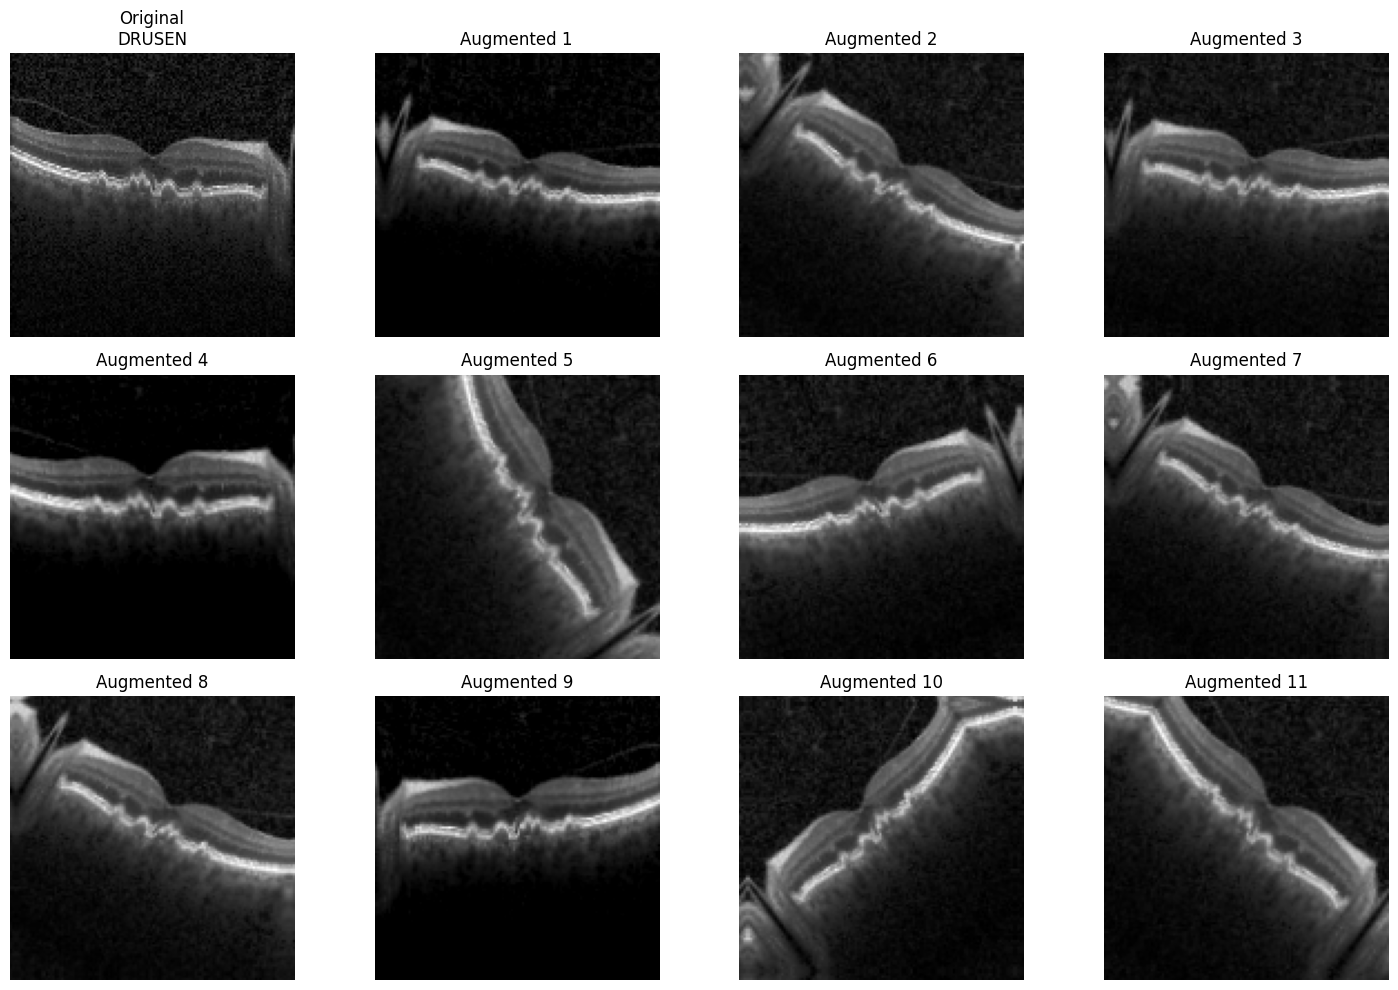

In [7]:
# Visualizar ejemplos de data augmentation
plt.figure(figsize=(15, 10))

# Tomar una imagen del dataset
for images, labels in train_ds.take(1):
    sample_image = images[0]
    sample_label = labels[0]
    
    # Mostrar la imagen original
    plt.subplot(3, 4, 1)
    plt.imshow(sample_image.numpy().squeeze(), cmap='gray')
    plt.title(f"Original\n{class_names[int(sample_label)]}")
    plt.axis('off')
    
    # Mostrar 11 versiones aumentadas
    for i in range(11):
        augmented_image = data_augmentation(tf.expand_dims(sample_image, 0), training=True)
        plt.subplot(3, 4, i + 2)
        plt.imshow(augmented_image[0].numpy().squeeze(), cmap='gray')
        plt.title(f"Augmented {i+1}")
        plt.axis('off')
    
plt.tight_layout()
plt.show()

## 2. Creación y Compilación del Modelo

In [8]:
# Crear y compilar el modelo
model = cnn_model.create_cnn(input_shape=(128, 128, 1), num_classes=4)
model = cnn_model.compile_model(model, learning_rate=0.000001)
cnn_model.print_model_summary(model)

Model: "BasicCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,287,620 (16.36 MB)

 Trainable params: 4,287,620 (16.36 MB)

 Non-trainable params: 0 (0.00 B)


✅ Parámetros totales: 4,287,620


## 3. Entrenamiento con Data Augmentation

Entrenamos el modelo utilizando el dataset aumentado. El data augmentation ayuda a reducir el sobreajuste y mejora la capacidad de generalización.

In [9]:
# Entrenamiento con dataset aumentado
EPOCHS = 1500
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy', 
        patience=50, 
        restore_best_weights=True,
        verbose=1
    )
]

history = model.fit(
    train_ds_augmented,  # <--- Usar dataset con Data Augmentation
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/1500
  7/299 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.3121 - loss: 10.2043  

I0000 00:00:1773332265.012137 2322470 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


299/299 ━━━━━━━━━━━━━━━━━━━━ 32s 67ms/step - accuracy: 0.3669 - loss: 4.9330 - val_accuracy: 0.4363 - val_loss: 1.5554
Epoch 2/1500
299/299 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.3980 - loss: 1.5929 - val_accuracy: 0.4683 - val_loss: 1.2128
Epoch 3/1500
299/299 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.4195 - loss: 1.3220 - val_accuracy: 0.4810 - val_loss: 1.1793
Epoch 4/1500
 68/299 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.4226 - loss: 1.2898

KeyboardInterrupt: 

## 4. Curvas de Aprendizaje y Evaluación

In [ ]:
# Curvas de aprendizaje
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.ylim(0, 1)
plt.title('Loss')
plt.legend()
plt.show()

In [ ]:
# Evaluación final
loss_train, acc_train = model.evaluate(train_ds, verbose=0)
loss_val, acc_val = model.evaluate(val_ds, verbose=0)
loss_test, acc_test = model.evaluate(test_ds, verbose=0)

print(f"\n📊 Resultados finales:")
print(f"   Train Accuracy: {acc_train:.4f}")
print(f"   Val Accuracy:   {acc_val:.4f}")
print(f"   Test Accuracy:  {acc_test:.4f}")
print(f"\n🔢 Parámetros del modelo: {model.count_params():,}")

## 5. Evaluación Detallada con Matriz de Confusión

In [ ]:
import seaborn as sns

# Obtener predicciones en el conjunto de test
y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Reporte de clasificación
print("\n📋 Reporte de clasificación:")
print(classification_report(y_true, y_pred, target_names=class_names))

# Matriz de confusión
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusión - CNN + Data Augmentation')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()